# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [2]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


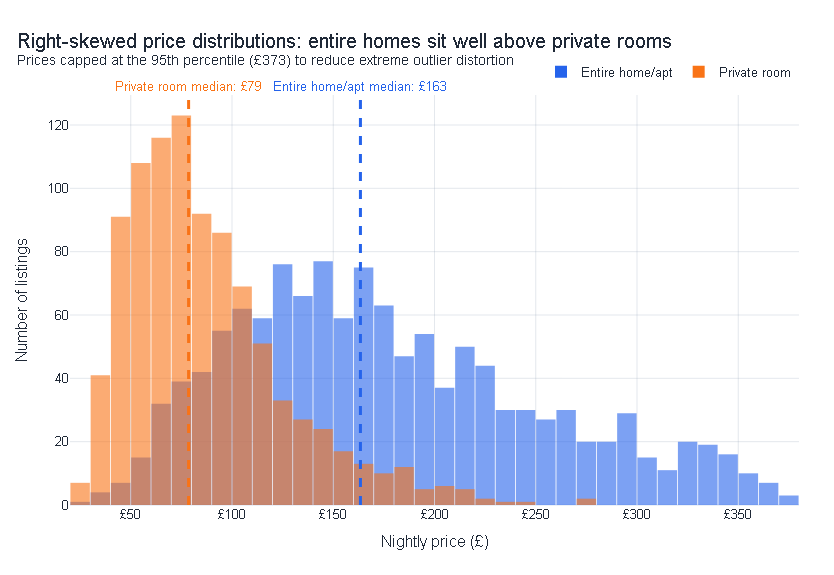

In [10]:
# Task 1 - Histogram: price by room type

import plotly.express as px

room_order = ["Entire home/apt", "Private room"]
room_colors = {
    "Entire home/apt": "#2563eb",
    "Private room": "#f97316"
}

df_task1 = df_cap[df_cap["room_type"].isin(room_order)].copy()

medians = (
    df_task1
    .groupby("room_type", as_index=False)["price"]
    .median()
    .rename(columns={"price": "median_price"})
)

fig = px.histogram(
    df_task1,
    x="price",
    color="room_type",
    color_discrete_map=room_colors,
    category_orders={"room_type": room_order},
    nbins=42,
    opacity=0.60,
    barmode="overlay",
    labels={
        "price": "Nightly price (£)",
        "room_type": "Room type",
        "count": "Number of listings"
    },
    title=(
        "Right-skewed price distributions: entire homes sit well above private rooms"
        "<br><sup>Prices capped at the 95th percentile (£{:.0f}) to reduce extreme outlier distortion</sup>"
    ).format(p95)
)

for row in medians.itertuples(index=False):
    fig.add_vline(
        x=row.median_price,
        line_width=3,
        line_dash="dash",
        line_color=room_colors[row.room_type],
        annotation_text=f"{row.room_type} median: £{row.median_price:.0f}",
        annotation_position="top",
        annotation_font_color=room_colors[row.room_type],
        annotation_bgcolor="rgba(255,255,255,0.85)"
    )

fig.update_layout(
    template="plotly_white",
    height=560,
    width=950,
    font=dict(family="Arial", size=13, color="#1f2937"),
    title=dict(x=0.02, xanchor="left", font=dict(size=20)),
    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    bargap=0.04,
    hovermode="x unified",
    margin=dict(l=70, r=35, t=95, b=70)
)

fig.update_xaxes(
    tickprefix="£",
    showgrid=True,
    gridcolor="rgba(148, 163, 184, 0.25)"
)

fig.update_yaxes(
    title="Number of listings",
    showgrid=True,
    gridcolor="rgba(148, 163, 184, 0.25)"
)

fig.show()


## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

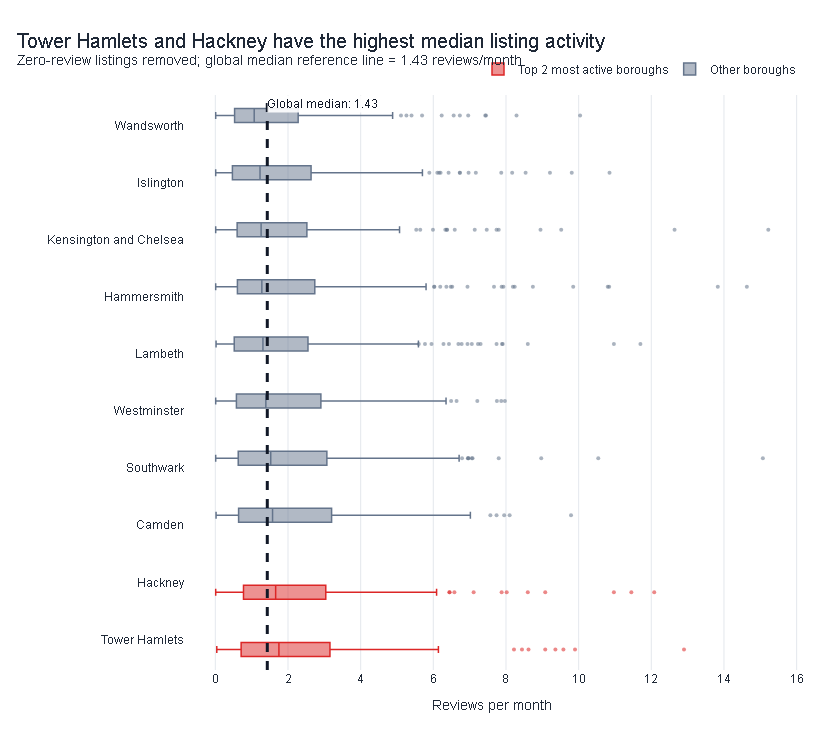

In [14]:
# Task 2 - Horizontal box plot: listing activity by borough

df_task2 = df[df["reviews_per_month"] > 0].copy()

borough_medians = (
    df_task2
    .groupby("neighbourhood")["reviews_per_month"]
    .median()
    .sort_values(ascending=False)
)

top_two = borough_medians.head(2).index.tolist()
borough_order = borough_medians.index.tolist()

df_task2["activity_group"] = np.where(
    df_task2["neighbourhood"].isin(top_two),
    "Top 2 most active boroughs",
    "Other boroughs"
)

global_median = df_task2["reviews_per_month"].median()

fig = px.box(
    df_task2,
    x="reviews_per_month",
    y="neighbourhood",
    color="activity_group",
    orientation="h",
    points="outliers",
    category_orders={
        "neighbourhood": borough_order[::-1],
        "activity_group": ["Top 2 most active boroughs", "Other boroughs"]
    },
    color_discrete_map={
        "Top 2 most active boroughs": "#dc2626",
        "Other boroughs": "#64748b"
    },
    labels={
        "reviews_per_month": "Reviews per month",
        "neighbourhood": "Borough",
        "activity_group": ""
    },
    title=(
        f"Tower Hamlets and Hackney have the highest median listing activity"
        f"<br><sup>Zero-review listings removed; global median reference line = {global_median:.2f} reviews/month</sup>"
    )
)

fig.add_vline(
    x=global_median,
    line_width=3,
    line_dash="dash",
    line_color="#111827",
    annotation_text=f"Global median: {global_median:.2f}",
    annotation_position="top right",
    annotation_font_color="#111827",
    annotation_bgcolor="rgba(255,255,255,0.90)"
)

fig.update_layout(
    template="plotly_white",
    height=720,
    width=980,
    font=dict(family="Arial", size=12, color="#1f2937"),
    title=dict(x=0.02, xanchor="left", font=dict(size=20)),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    boxmode="group",
    margin=dict(l=185, r=35, t=95, b=65)
)

fig.update_traces(
    marker=dict(size=4, opacity=0.55),
    line=dict(width=1.5)
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="rgba(148, 163, 184, 0.25)",
    zeroline=False
)

fig.update_yaxes(
    title=None,
    showgrid=False
)

fig.show()


## Key Insights

### Task 1: Price Distribution by Room Type

The price distribution is strongly right-skewed, meaning most Airbnb listings are concentrated at lower nightly prices, while fewer listings charge much higher prices.

After capping price outliers at the 95th percentile, entire homes/apartments still show a much higher price distribution than private rooms. The median price for an entire home/apartment is approximately **£163**, compared with approximately **£79** for a private room.

This shows that entire homes/apartments typically cost about **twice as much** as private rooms. Private rooms are more tightly clustered around lower prices, while entire homes/apartments have a wider spread, suggesting more variation in size, location, and listing quality.

### Task 2: Listing Activity by Borough

Reviews per month were used as a proxy for listing activity, with zero-review listings removed because they may represent new or inactive listings.

The box plot shows that **Tower Hamlets** and **Hackney** have the highest median listing activity among the boroughs. Tower Hamlets has a median of approximately **1.76 reviews per month**, while Hackney has approximately **1.66 reviews per month**.

Most boroughs have relatively similar activity levels, but the top boroughs stand out with slightly higher central activity. The visible outliers show that some individual listings receive much higher review activity than the typical listing in their borough.

Overall, the analysis suggests that Airbnb demand is not evenly distributed across London. Some boroughs, especially Tower Hamlets and Hackney, appear to have more active listings, while price differences are mainly driven by room type.
